# 🎯 Ziel dieser Lektion: Convolutional Neural Networks (CNN)

**Was wollen wir erreichen?** 
Wir wollen lernen, wie man neuronale Netze baut, die "sehen" können. Wir nutzen Faltungsnetzwerke (CNNs), um räumliche Muster in Bildern (wie Kanten, Formen und Texturen) zu erkennen, anstatt Bilder einfach nur abzuflachen.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Ein Bild-Datensatz (z.B. MNIST-Ziffern oder CIFAR-10) als 2D- bzw. 3D-Tensoren (Pixel und Farbkanäle), bei denen einfache Netze (MLPs) räumliche Informationen verlieren würden.
- **Endziel (Gesucht):** Ein tiefes CNN-Modell, das durch Faltung und Pooling automatisch visuelle Merkmale extrahiert und komplexe Bilder mit hoher Genauigkeit klassifiziert.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Bild-Tensoren laden` ➔ `Faltungsschichten (Conv2D) anwenden` ➔ `Dimensionen mit Pooling reduzieren` ➔ `Merkmale abflachen (Flatten/GlobalAverage)` ➔ `Wahrscheinlichkeiten klassifizieren (Dense/Softmax)`

---

## Exercise 1

**Dataset Used:** CIFAR-10 (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `import tensorflow as tf` | Importiert die TensorFlow-Bibliothek für neuronale Netze. |
| `import numpy as np` | Importiert NumPy für numerische Matrizenoperationen. |
| `import matplotlib.pyplot as plt` | Importiert Matplotlib zur Darstellung von Graphen. |
| `from sklearn.metrics import classification_report` | Importiert eine Funktion zur genauen Auswertung der Klassifikationsergebnisse. |
| `tf.keras.datasets.cifar10.load_data()` | Lädt den CIFAR-10 Datensatz (60.000 kleine Farbbilder, aufgeteilt in 50k Training und 10k Test). |
| `x_train.astype("float32") / 255.0` | Konvertiert die Pixel (0-255) zu Fließkommazahlen und normalisiert sie in den Bereich [0, 1]. |
| `klassen_namen = [...]` | Erstellt eine Liste mit den Text-Namen der 10 Kategorien in CIFAR-10. |
| `tf.keras.Sequential([...])` | Baut ein fortlaufendes Modell auf. |
| `tf.keras.Input(shape=(32, 32, 3))` | Definiert das Eingabeformat: 32x32 Pixel, 3 Farbkanäle (RGB). |
| `tf.keras.layers.Conv2D(32, (3, 3), padding="same")` | Faltungsschicht mit 32 Filtern der Größe 3x3. `padding="same"` bedeutet, dass die Bildgröße nicht schrumpft. |
| `tf.keras.layers.BatchNormalization()` | Normalisiert die Werte (Feature Maps) des aktuellen Batches, um das Training zu beschleunigen und robuster zu machen. |
| `tf.keras.layers.Activation("relu")` | Wendet die ReLU-Aktivierungsfunktion ($f(x)=\max(0,x)$) auf die normalisierten Werte an. |
| `tf.keras.layers.MaxPooling2D((2, 2))` | Halbiert die Dimensionen der Bild-Tensoren, indem jeweils der höchste Wert in 2x2 Fenstern genommen wird. |
| `tf.keras.layers.Dropout(0.25)` | Deaktiviert zufällig 25% der Neuronen in jedem Trainingsschritt, um Overfitting zu verhindern. |
| `tf.keras.layers.GlobalAveragePooling2D()` | Bildet für jeden Farbkanal den räumlichen Durchschnitt. Reduziert den Tensor flach und macht `Flatten()` überflüssig. |
| `tf.keras.layers.Dense(10, activation="softmax")` | Ausgabe-Schicht für 10 Klassen mit Softmax für Wahrscheinlichkeitswerte. |
| `modell.compile(...)` | Konfiguriert den Optimizer (adam), Loss (sparse_categorical_crossentropy) und Metrik. |
| `modell.fit(..., epochs=3)` | Trainiert das Modell für 3 Epochen über den gesamten Trainingsdatensatz. |
| `modell.evaluate(x_test, y_test)` | Berechnet den Verlust und die Test-Genauigkeit. |
| `np.argmax(modell.predict(x_test), axis=1)` | Ermittelt die Klassen-ID mit der jeweils höchsten vorhergesagten Wahrscheinlichkeit für die Testbilder. |
| `classification_report(y_test, preds, target_names=...)` | Erstellt einen Bericht mit Precision, Recall und f1-score für jede der 10 Klassen. |
| `plt.subplots(...)`, `plot(...)`, `savefig(...)` | Funktionen zum Zeichnen, Speichern und Anzeigen der Verlust- und Genauigkeitsgraphen. |

TensorFlow Version: 2.21.0
Trainingsdaten: (50000, 32, 32, 3)  Testdaten: (10000, 32, 32, 3)


Model: "CIFAR10_Tiefes_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,434 (372.79 KB)

 Trainable params: 94,986 (371.04 KB)

 Non-trainable params: 448 (1.75 KB)


Starte Training auf CIFAR-10 (20 Epochen)...
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4298 - loss: 1.5689 - val_accuracy: 0.4258 - val_loss: 1.5530 - learning_rate: 0.0010
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5356 - loss: 1.2971 - val_accuracy: 0.5014 - val_loss: 1.4325 - learning_rate: 0.0010
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5784 - loss: 1.1840 - val_accuracy: 0.4822 - val_loss: 1.3787 - learning_rate: 0.0010

Test-Verlust:     1.3838
Test-Genauigkeit: 0.4798

Klassifikationsbericht (CIFAR-10):
              precision    recall  f1-score   support

    Flugzeug       0.70      0.31      0.43      1000
        Auto       0.91      0.28      0.43      1000
       Vogel       0.59      0.25      0.35      1000
       Katze       0.44      0.27      0.33      1000
         Reh       0.25      0.83      0.38      1000
        Hund       0.60      0.34      0.44      1000
      Frosch       0.61      

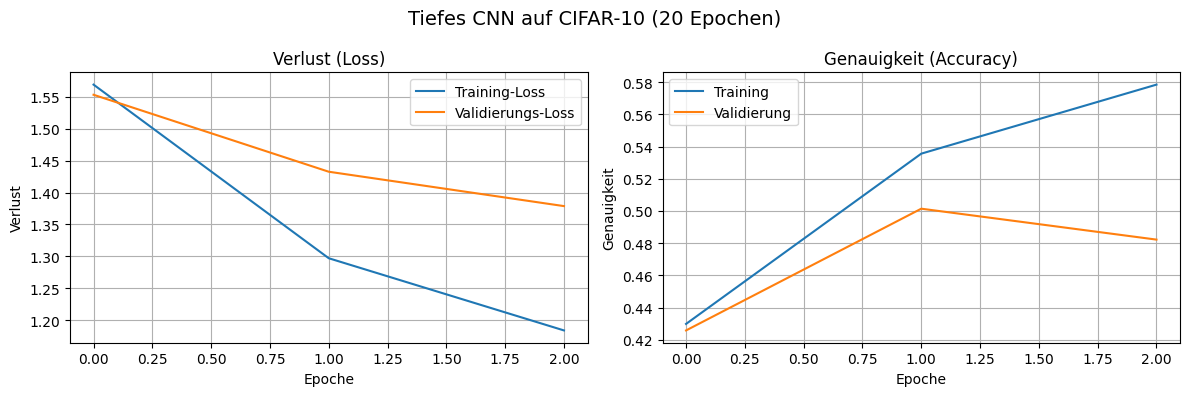

Diagramm gespeichert: F7_1_cifar10_training.png


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Fortgeschrittene
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
import matplotlib

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# CIFAR-10 Klassenbezeichnungen
klassen_namen = ["Flugzeug", "Auto", "Vogel", "Katze", "Reh",
                 "Hund", "Frosch", "Pferd", "Schiff", "LKW"]

# ── 1. CIFAR-10 laden ─────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
y_train = y_train.flatten()
y_test  = y_test.flatten()
print(f"Trainingsdaten: {x_train.shape}  Testdaten: {x_test.shape}")

# ── 2. Tiefes CNN mit Batch Normalization aufbauen ────────────────────────────
modell = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    # Block 1: 32 Filter
    tf.keras.layers.Conv2D(32, (3, 3), padding="same", ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.2),

    # Block 2: 64 Filter
    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),

    # Block 3: 128 Filter
    tf.keras.layers.Conv2D(128, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.4),

    # Globales Pooling statt Flatten
    tf.keras.layers.GlobalAveragePooling2D(),

    # Dichte Ausgabeschicht
    tf.keras.layers.Dense(10, activation="softmax"),
], name="CIFAR10_Tiefes_CNN")

# ── 3. Kompilieren ────────────────────────────────────────────────────────────
modell.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
modell.summary()

# ── 4. Training (20 Epochen) ──────────────────────────────────────────────────
print("\nStarte Training auf CIFAR-10 (20 Epochen)...")
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy", factor=0.5, patience=3, verbose=1
    )
]
history = modell.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# ── 5. Evaluation und Klassifikationsbericht ──────────────────────────────────
test_loss, test_acc = modell.evaluate(x_test, y_test, verbose=0)
print(f"\nTest-Verlust:     {test_loss:.4f}")
print(f"Test-Genauigkeit: {test_acc:.4f}")

vorhersagen = np.argmax(modell.predict(x_test, verbose=0), axis=1)
print("\nKlassifikationsbericht (CIFAR-10):")
print(classification_report(y_test, vorhersagen, target_names=klassen_namen))

# ── 6. Visualisierung ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Training-Loss")
axes[0].plot(history.history["val_loss"], label="Validierungs-Loss")
axes[0].set_title("Verlust (Loss)")
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Verlust")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"],     label="Training")
axes[1].plot(history.history["val_accuracy"], label="Validierung")
axes[1].set_title("Genauigkeit (Accuracy)")
axes[1].set_xlabel("Epoche")
axes[1].set_ylabel("Genauigkeit")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Tiefes CNN auf CIFAR-10 (20 Epochen)", fontsize=14)
plt.tight_layout()
plt.savefig("F7_1_cifar10_training.png", dpi=100)
plt.show()
print("Diagramm gespeichert: F7_1_cifar10_training.png")


## Exercise 2

**Dataset Used:** CIFAR-10 (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

**Ziel / Zweck:**
In dieser Übung befassen wir uns mit 'Data Augmentation' (Datenaugmentierung). Der Zweck liegt darin, durch zufällige Transformationen (Spiegeln, Drehen, Zoomen) der vorhandenen Trainingsbilder den Datensatz künstlich zu vergrößern. Dadurch soll das Netzwerk verallgemeinern lernen und das Overfitting (Auswendiglernen der Daten) verringern.


### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `tf.keras.Sequential([...], name="Augmentierung")` | Erstellt einen Pipeline-Graphen für Bild-Transformationen, die zur Laufzeit im Training passieren. |
| `tf.keras.layers.RandomRotation(0.1)` | Rotiert die Bilder zufällig um bis zu ±10% von $360^\circ$ (also $\pm 36^\circ$). |
| `tf.keras.layers.RandomZoom(0.1)` | Zoomt das Bild zufällig hinein oder heraus (um bis zu 10%). |
| `tf.keras.layers.RandomContrast(0.1)` | Ändert den Kontrast der Bilder zufällig um $\pm 10\%$. |
| `tf.keras.layers.RandomFlip("horizontal")` | Spiegelt das Bild mit 50% Wahrscheinlichkeit horizontal (rechts-links). |
| `def baue_modell():` | Definiert eine Hilfsfunktion, um dasselbe Basis-CNN mehrfach identisch aufzubauen, um Vergleiche zu ermöglichen. |
| `modell_ohne = baue_modell()` | Baut das Netzwerk ohne Augmentierung. |
| `modell_mit = tf.keras.Sequential([augmentierung, baue_modell()])` | Baut das Netzwerk, wobei die Bilder VOR dem Eintreffen in das CNN live augmentiert werden. |
| `modell.fit(..., validation_split=0.15)` | Startet das Training für 3 Epochen. Wir zweigen 15% der Daten zur Validierung ab, um echtes Overfitting zu messen. |
| `history_ohne.history["val_accuracy"][-1]` | Holt sich exakt den letzten Genauigkeits-Wert nach Abschluss der Epochen. |
| `(acc_mit - acc_ohne)*100` | Berechnet die Differenz der Genauigkeiten in Prozentpunkten. |
| `augmentierung(probe, training=True)` | Wendet den Augmentierungsgraphen manuell auf ein Bild an (nur im Trainingsmodus `True` wird wirklich augmentiert). |
| `tf.clip_by_value(aug_bild, 0, 1)` | Stellt sicher, dass die Pixelwerte nach dem Kontrastwechsel nicht unter 0 oder über 1 fallen (sonst Warnungen beim Plotten). |
| `axes[...].imshow(...)` | Zeichnet die erzeugten Bilder in das Subplot-Raster. |

TensorFlow Version: 2.21.0
Trainingsdaten (Teilmenge): (10000, 32, 32, 3)

Training OHNE Augmentierung...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.2898 - loss: 1.9080 - val_accuracy: 0.1246 - val_loss: 2.7687
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3924 - loss: 1.6428 - val_accuracy: 0.1583 - val_loss: 2.7744
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4545 - loss: 1.4890 - val_accuracy: 0.3792 - val_loss: 1.7262

Training MIT Augmentierung...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2654 - loss: 1.9746 - val_accuracy: 0.1541 - val_loss: 2.6299
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3462 - loss: 1.7512 - val_accuracy: 0.1758 - val_loss: 2.9260
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3929 - loss: 1.6462 - val_accuracy: 0.2972 - val_loss: 1.9393

Test-Genauigkeit OHNE Augmentierung: 0.3792
Test-Genauigkeit MIT  Augmentierung: 0.2972
Verbes

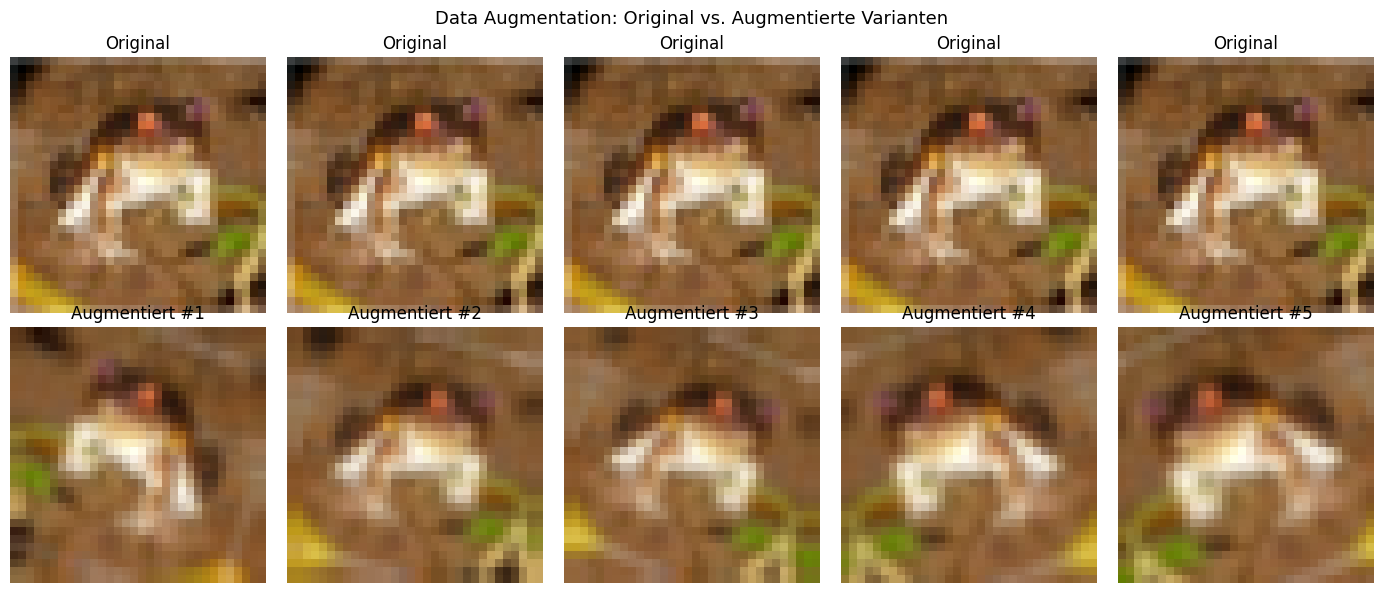

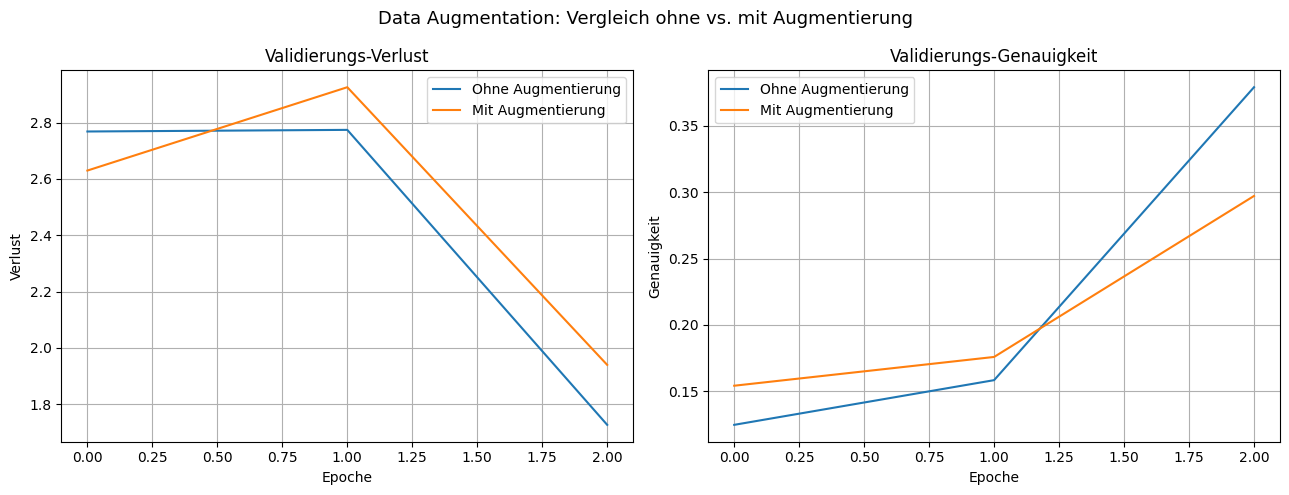

Diagramme gespeichert: F7_2_augmentierung_*.png


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Fortgeschrittene
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# ── 1. CIFAR-10 laden ─────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
y_train = y_train.flatten()
y_test  = y_test.flatten()

# Teilmenge für schnelleres Training
x_train_klein = x_train[:10000]
y_train_klein = y_train[:10000]
print(f"Trainingsdaten (Teilmenge): {x_train_klein.shape}")

# ── 2. Augmentierungs-Pipeline mit Keras-Schichten ───────────────────────────
augmentierung = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="Augmentierungs_Pipeline")

# ── 3. Modell-Fabrik ──────────────────────────────────────────────────────────
def cnn_erstellen(mit_augmentierung=False, name="CNN"):
    schichten = []
    if mit_augmentierung:
        # Augmentierung nur im Training aktiv
        schichten.append(augmentierung)
    schichten += [
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu",
                               padding="same", ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
    m = tf.keras.Sequential(schichten, name=name)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return m

# ── 4. Modell OHNE Augmentierung ──────────────────────────────────────────────
print("\nTraining OHNE Augmentierung...")
modell_ohne = cnn_erstellen(mit_augmentierung=False, name="Ohne_Augmentierung")
history_ohne = modell_ohne.fit(
    x_train_klein, y_train_klein,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

# ── 5. Modell MIT Augmentierung ───────────────────────────────────────────────
print("\nTraining MIT Augmentierung...")
modell_mit = cnn_erstellen(mit_augmentierung=True, name="Mit_Augmentierung")
history_mit = modell_mit.fit(
    x_train_klein, y_train_klein,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

# ── 6. Vergleich ──────────────────────────────────────────────────────────────
acc_ohne, acc_mit = (history_ohne.history["val_accuracy"][-1],
                     history_mit.history["val_accuracy"][-1])
print(f"\nTest-Genauigkeit OHNE Augmentierung: {acc_ohne:.4f}")
print(f"Test-Genauigkeit MIT  Augmentierung: {acc_mit:.4f}")
print(f"Verbesserung durch Augmentierung:    {(acc_mit - acc_ohne)*100:+.2f}%")

# ── 7. Augmentierte Bilder visualisieren ──────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
probe = x_train[:1]  # ein Bild

for i in range(5):
    axes[0, i].imshow(probe[0])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    aug_bild = augmentierung(probe, training=True)[0]
    axes[1, i].imshow(tf.clip_by_value(aug_bild, 0, 1))
    axes[1, i].set_title(f"Augmentiert #{i+1}")
    axes[1, i].axis("off")

plt.suptitle("Data Augmentation: Original vs. Augmentierte Varianten", fontsize=13)
plt.tight_layout()
plt.savefig("F7_2_augmentierung_beispiele.png", dpi=100)
plt.show()

# ── 8. Trainingsverläufe vergleichen ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_ohne.history["val_loss"], label="Ohne Augmentierung")
axes[0].plot(history_mit.history["val_loss"],  label="Mit Augmentierung")
axes[0].set_title("Validierungs-Verlust")
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Verlust")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_ohne.history["val_accuracy"], label="Ohne Augmentierung")
axes[1].plot(history_mit.history["val_accuracy"],  label="Mit Augmentierung")
axes[1].set_title("Validierungs-Genauigkeit")
axes[1].set_xlabel("Epoche")
axes[1].set_ylabel("Genauigkeit")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Data Augmentation: Vergleich ohne vs. mit Augmentierung", fontsize=13)
plt.tight_layout()
plt.savefig("F7_2_augmentierung_vergleich.png", dpi=100)
plt.show()
print("Diagramme gespeichert: F7_2_augmentierung_*.png")


## Exercise 3

**Dataset Used:** MNIST (keras.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

**Ziel / Zweck:**
Diese Aufgabe demonstriert, wie sich verschiedene Hyperparameter (wie die Anzahl der Filter, Kernelgrößen und Pooling-Methoden) auf die Trainingszeit und Genauigkeit eines CNNs auswirken. Der Zweck ist es, durch gezieltes Ausprobieren (eine kleine Form des Hyperparameter-Tunings) die effizienteste und beste Architektur für das jeweilige Problem zu finden.


### Verwendete Codes und Funktionen

| Code / Funktion | Zeile für Zeile Erklärung (Deutsch) |
|---|---|
| `import time` | Importiert das Zeit-Modul, um die Dauer des Trainings zu messen. |
| `x_train[:2000]` / `x_test[:500]` | Schneidet die Datensätze extrem ab, damit wir in annehmbarer Zeit viele CNNs durchtesten können. |
| `def cnn_variante(filter_anzahl, kernel_groesse, pooling_typ, name):` | Eine Funktion (Fabrik), die ein Modell entsprechend der übergebenen Hyperparameter (Konfiguration) generiert. |
| `if pooling_typ == "Max": ... else: ...` | Überprüft den Parameter `pooling_typ` als String und wählt die entsprechende Keras-Schichtklasse (Max vs. Average) aus. |
| `tf.keras.layers.Conv2D(...)` | Die Parameteranzahl für Filter und Kernelgröße werden nun dynamisch in die Definition des CNNs eingesetzt. |
| `kombinationen = [...]` | Eine Liste von Python-Dictionaries. Jedes Dictionary repräsentiert einen anderen Hyperparameter-Satz, der getestet werden soll. |
| `for i, k in enumerate(kombinationen):` | Schleife über alle Dictionaries (Hyperparameter-Kombinationen). `k` enthält die aktuellen Parameter. |
| `time.perf_counter()` | Stoppuhr-Funktion. Wir merken uns die Zeit vor und nach `fit()`, um die genaue Dauer des Trainings in Sekunden zu berechnen. |
| `m.count_params()` | Zählt und liefert die exakte Anzahl der mathematischen Gewichte/Parameter im aktuellen Modell. |
| `ergebnisse.append({...})` | Speichert alle Kennzahlen (Genauigkeit, Trainingszeit, Parameteranzahl) eines Laufs in eine Ergebnis-Liste. |
| `sorted(ergebnisse, key=lambda x: x["Test-Acc"], reverse=True)` | Sortiert die Ergebnisliste absteigend (von bester zu schlechtester Genauigkeit). |
| `max(ergebnisse, key=lambda x: x["Test-Acc"])` | Findet das Dictionary (den Lauf), welches die höchste Genauigkeit (`Test-Acc`) besitzt. |
| `axes[0].scatter(zeiten, akk, s=100, c=..., cmap="tab10")` | Zeichnet ein Streudiagramm (Punktwolke), bei dem auf der X-Achse die Trainingszeit und auf der Y-Achse die Genauigkeit liegt. |
| `axes[0].annotate(name, (zeiten[i], akk[i]))` | Schreibt den Konfigurations-Namen neben jeden Punkt in das Streudiagramm. |

TensorFlow Version: 2.21.0
Trainingsdaten: (2000, 28, 28, 1)  Testdaten: (500, 28, 28, 1)

[1/7] Trainiere: F16_K3_PMax
  → Test-Acc: 0.8900 | Params: 201,578 | Zeit: 1.6s

[2/7] Trainiere: F32_K3_PMax
  → Test-Acc: 0.8940 | Params: 402,442 | Zeit: 1.7s

[3/7] Trainiere: F64_K3_PMax
  → Test-Acc: 0.9040 | Params: 804,170 | Zeit: 2.0s

[4/7] Trainiere: F16_K5_PMax
  → Test-Acc: 0.9160 | Params: 201,834 | Zeit: 1.3s

[5/7] Trainiere: F32_K5_PMax
  → Test-Acc: 0.9020 | Params: 402,954 | Zeit: 1.7s

[6/7] Trainiere: F32_K3_PAverage
  → Test-Acc: 0.8960 | Params: 402,442 | Zeit: 1.9s

[7/7] Trainiere: F64_K3_PAverage
  → Test-Acc: 0.9040 | Params: 804,170 | Zeit: 2.0s

── Vergleichstabelle ──
Name                         Filter Kernel     Pool   Params      Acc     Zeit
------------------------------------------------------------------------------
F16_K5_PMax                      16      5      Max  201,834   0.9160     1.4s
F64_K3_PMax                      64      3      Max  804,170   0.9

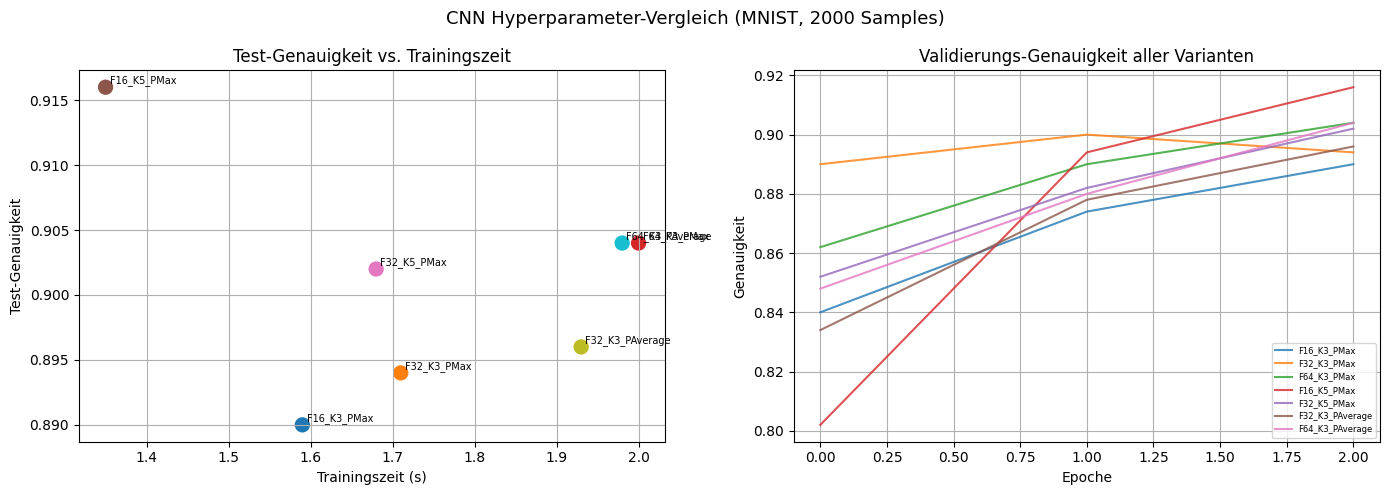

Diagramm gespeichert: F7_3_hyperparameter_vergleich.png


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 7: Convolutional Neural Networks (CNN)
# Niveau: Fortgeschrittene
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import time

print("TensorFlow Version:", tf.__version__)

# ── 1. MNIST-Teilmenge (2000 Samples) ────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[:2000].astype("float32")[..., np.newaxis] / 255.0
y_train = y_train[:2000]
x_test  = x_test[:500].astype("float32")[..., np.newaxis]   / 255.0
y_test  = y_test[:500]
print(f"Trainingsdaten: {x_train.shape}  Testdaten: {x_test.shape}")

# ── 2. CNN-Fabrik mit variablen Hyperparametern ───────────────────────────────
def cnn_variante(filter_anzahl, kernel_groesse, pooling_typ, name):
    """Erstellt ein kleines CNN mit anpassbaren Hyperparametern."""
    if pooling_typ == "Max":
        pool_layer = tf.keras.layers.MaxPooling2D((2, 2))
    else:
        pool_layer = tf.keras.layers.AveragePooling2D((2, 2))

    modell = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(
            filter_anzahl, (kernel_groesse, kernel_groesse),
            activation="relu", padding="same",
            
        ),
        pool_layer,
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ], name=name)

    modell.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modell

# ── 3. Hyperparameter-Kombinationen definieren ────────────────────────────────
kombinationen = [
    {"filter": 16, "kernel": 3, "pooling": "Max"},
    {"filter": 32, "kernel": 3, "pooling": "Max"},
    {"filter": 64, "kernel": 3, "pooling": "Max"},
    {"filter": 16, "kernel": 5, "pooling": "Max"},
    {"filter": 32, "kernel": 5, "pooling": "Max"},
    {"filter": 32, "kernel": 3, "pooling": "Average"},
    {"filter": 64, "kernel": 3, "pooling": "Average"},
]

# ── 4. Alle Varianten trainieren und vergleichen ──────────────────────────────
ergebnisse = []
verlauf_alle = {}

for i, k in enumerate(kombinationen):
    name = f"F{k['filter']}_K{k['kernel']}_P{k['pooling']}"
    print(f"\n[{i+1}/{len(kombinationen)}] Trainiere: {name}")
    m = cnn_variante(k["filter"], k["kernel"], k["pooling"], name)

    start = time.perf_counter()
    history = m.fit(
        x_train, y_train,
        epochs=3,
        batch_size=32,
        validation_data=(x_test, y_test),
        verbose=0
    )
    trainingszeit = time.perf_counter() - start

    test_loss, test_acc = m.evaluate(x_test, y_test, verbose=0)
    params = m.count_params()

    ergebnisse.append({
        "Name":       name,
        "Filter":     k["filter"],
        "Kernel":     k["kernel"],
        "Pooling":    k["pooling"],
        "Params":     params,
        "Test-Acc":   test_acc,
        "Zeit (s)":   round(trainingszeit, 2),
    })
    verlauf_alle[name] = history.history["val_accuracy"]
    print(f"  → Test-Acc: {test_acc:.4f} | Params: {params:,} | Zeit: {trainingszeit:.1f}s")

# ── 5. Ergebnistabelle ausgeben ───────────────────────────────────────────────
print("\n── Vergleichstabelle ──")
header = f"{'Name':<28} {'Filter':>6} {'Kernel':>6} {'Pool':>8} {'Params':>8} {'Acc':>8} {'Zeit':>8}"
print(header)
print("-" * len(header))
for r in sorted(ergebnisse, key=lambda x: x["Test-Acc"], reverse=True):
    print(f"{r['Name']:<28} {r['Filter']:>6} {r['Kernel']:>6} "
          f"{r['Pooling']:>8} {r['Params']:>8,} {r['Test-Acc']:>8.4f} {r['Zeit (s)']:>7.1f}s")

bestes = max(ergebnisse, key=lambda x: x["Test-Acc"])
print(f"\nBeste Konfiguration: {bestes['Name']} → Acc: {bestes['Test-Acc']:.4f}")

# ── 6. Visualisierung ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genauigkeit vs. Zeit
akk   = [r["Test-Acc"]  for r in ergebnisse]
zeiten = [r["Zeit (s)"] for r in ergebnisse]
namen  = [r["Name"]     for r in ergebnisse]

axes[0].scatter(zeiten, akk, s=100, c=range(len(ergebnisse)), cmap="tab10")
for i, name in enumerate(namen):
    axes[0].annotate(name, (zeiten[i], akk[i]), fontsize=7,
                     xytext=(3, 3), textcoords="offset points")
axes[0].set_title("Test-Genauigkeit vs. Trainingszeit")
axes[0].set_xlabel("Trainingszeit (s)")
axes[0].set_ylabel("Test-Genauigkeit")
axes[0].grid(True)

# Lernkurven
for name, val_accs in verlauf_alle.items():
    axes[1].plot(val_accs, label=name, alpha=0.8)
axes[1].set_title("Validierungs-Genauigkeit aller Varianten")
axes[1].set_xlabel("Epoche")
axes[1].set_ylabel("Genauigkeit")
axes[1].legend(fontsize=6)
axes[1].grid(True)

plt.suptitle("CNN Hyperparameter-Vergleich (MNIST, 2000 Samples)", fontsize=13)
plt.tight_layout()
plt.savefig("F7_3_hyperparameter_vergleich.png", dpi=100)
plt.show()
print("Diagramm gespeichert: F7_3_hyperparameter_vergleich.png")
